In [ ]:
# Thach Ta
# 1001744101

# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

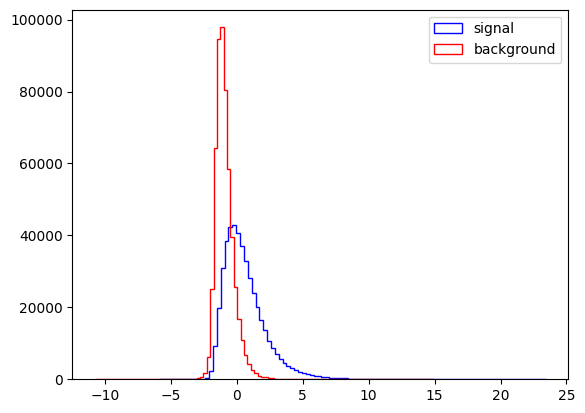

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

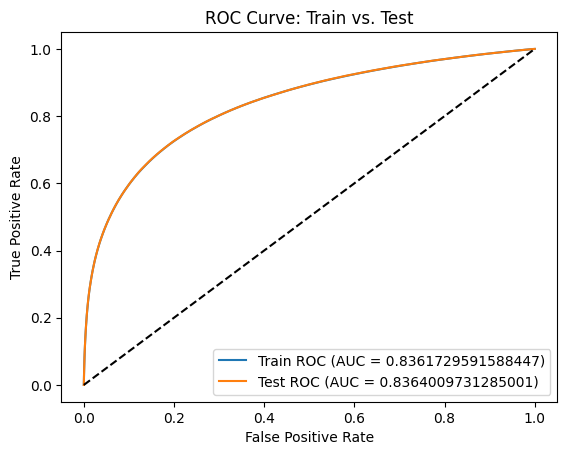

In [7]:
# Importing ROC_curves and AUC from scikit-learn
from sklearn.metrics import roc_curve, auc

# Higher score -> More likely signal
# Lower score -> More likely background
# -------------------------------------
# Getting model scores for train and test
train_scores = Fisher.decision_function(X_Train)
test_scores = Fisher.decision_function(X_Test)

# TPR (True Positive Rate) = Signal efficiency
# FPR (False Positive Rate) = Background contamination
# -------------------------------------
# Computing ROC Curves for train and test
fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)
fpr_test, tpr_test, _ = roc_curve(y_Test, test_scores)

# Computing AUC (Area under ROC curve)
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

# Plotting
plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:})")

# Setting random guess line:
plt.plot([0, 1], [0, 1], "k--")

# Plot labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs. Test")
plt.legend()
plt.show()

In [21]:
# There seems to be no bias present, so the model generalizes well

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [8]:
# From the dataset:
# -------------------------------------
# VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
#          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
#          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
#
# [First 8 features are directly measured, raw data]
# lepton 1 pT: momentum transverse to the beamline of lepton 1
# lepton 1 eta: pseudo-rapidity of lepton 1
# lepton 1 phi: azimuthal angle of lepton 1
# lepton 2 pT: momentum transverse to the beamline of lepton 2
# lepton 2 eta: pseudo-rapidity of lepton 2
# lepton 2 phi: azimuthal angle of lepton 2
# missing energy magnitude: the amount of missing transverse momentum
# missing energy phi: the azimuthal angle of the missing transverse momentum

# [Last 10 features are engineered variables]
# -------------------------------------
# Raw variables:
raw_vars = ["l_1_pT", "l_1_eta","l_1_phi",
            "l_2_pT", "l_2_eta", "l_2_phi",
            "MET", "MET_phi"]

# Feature variables:
feature_vars = ["MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

# Combined variables:
combined_vars = raw_vars + feature_vars

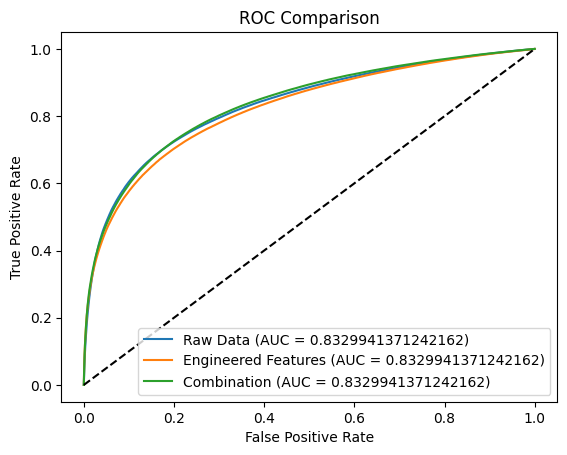

In [9]:
# Training 3 models:
# Reusable function that takes in a list of variables and trains using those variables
def train_and_roc(var_list):
    # Creates a fresh, independent model
    model = DA.LinearDiscriminantAnalysis()

    # Specifying variables as inputs
    X_train = Train_Sample[var_list]
    X_test = Test_Sample[var_list]

    # Training the model to separate signal from background
    model.fit(X_train, y_Train)

    # Getting prediction scores to build the ROC curve
    scores = model.decision_function(X_test)

    # Building ROC curve
    # tpr = signal efficiency
    # fpr = background contamination
    # roc_auc = overall performance score
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)

    # Returning results
    return fpr, tpr, roc_auc

# Training case for raw data:
fpr_raw, tpr_raw, auc_raw = train_and_roc(raw_vars)
# Training case for engineered features:
fpr_feat, tpr_feat, auc_feat = train_and_roc(feature_vars)
# Training case for the combination:
fpr_comb, tpr_comb, auc_comb = train_and_roc(combined_vars)

# Plotting everything together:
plt.figure()

# Curves for each case
plt.plot(fpr_raw, tpr_raw, label=f"Raw Data (AUC = {auc_raw:})")
plt.plot(fpr_feat, tpr_feat, label=f"Engineered Features (AUC = {auc_raw:})")
plt.plot(fpr_comb, tpr_comb, label=f"Combination (AUC = {auc_raw:})")

# Setting random guess line:
plt.plot([0, 1], [0, 1], "k--")

# Plot labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.show()

In [ ]:
# All AUC values are the same
# Model likely not gaining new information from features

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [ ]:
# Part a)
# -------------------------------------------------------
# 3 classifiers I choose:
# [!!!] I consulted an LLM to help me choose
# Random Forest, Logistic Regression, Gradient Boosting
# Random forests help with nonlinear and complex interactions
# Logistic regression is quick and easy
# Gradient boosting, which has higher accuracy
# EDIT: Used gradient boosting at first, but apparently histogram gradient boosting is faster and better for larger datasaets

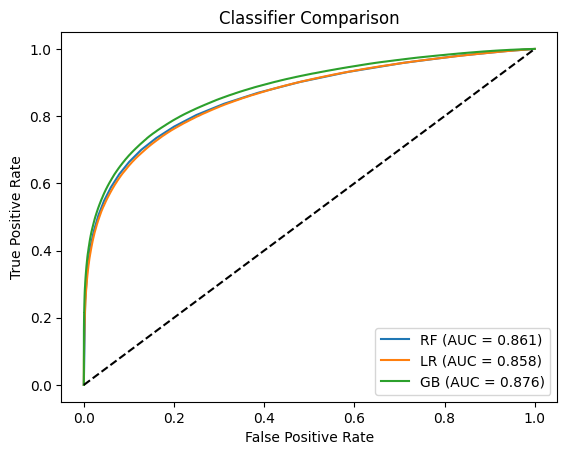

In [11]:
# Part b)
# -------------------------------------------------------
# Importing the techniques
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

# For this exercise, I'll use a smaller sample for N_Train
N_Train = 100000

# Function to test the techniques
# Modified from previous exercise's train_and_roc() function
def evaluate_classifier(model, var_list):
    # Selecting features
    X_train = Train_Sample[var_list]
    X_test = Test_Sample[var_list]

    # Train model
    model.fit(X_train, y_Train)

    # Getting scores:
    # Different techniques output scores differently
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
    # Random Forest output scores through predict_proba()
    else:
        # predict_proba() returns data we need to slice
        scores = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)

    # Returning results
    return fpr, tpr, roc_auc, scores

# Random forest
# n_estimators: decision trees
# Each tree makes a prediction and we get the average of all trees
rf = RandomForestClassifier(n_estimators=20)
# Logistic regression with max iterations and saga helps speed it up
lr = LogisticRegression(max_iter=200, solver="saga")
# Histogram Gradient boosting
# Builds trees sequentially where each tree focuses on previous mistakes
gb = HistGradientBoostingClassifier()

# Training case for Random Forest:
fpr_rf, tpr_rf, auc_rf, _ = evaluate_classifier(rf, combined_vars)
# Training case for SVM:
fpr_lr, tpr_lr, auc_lr, _ = evaluate_classifier(lr, combined_vars)
# Training case for Gradient Boosting:
fpr_gb, tpr_gb, auc_gb, _ = evaluate_classifier(gb, combined_vars)

# Plotting everything
plt.figure()

plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {auc_rf:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {auc_lr:.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"GB (AUC = {auc_gb:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier Comparison")
plt.legend()
plt.show()

In [13]:
# Histogram gradient boosting seems to be the best

In [20]:
# Part c)
# Equation for maximal significance: sigma_S = N_S/sqrt((NS + N_B))
# Different scenarios of (N_S, N_B) from last lab:
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)]

# From the classifier, we get a score of background/signal-like events
# We need to choose a threshold to determine background/signal
# Multiply the signal/background efficiencies from method with N_S and N_B to get Np_S & Np_B 
# Then we pick the threshold that gives the largest sigma after calculations

# Gives a score per event ([3] to get scores)
scores = evaluate_classifier(gb, combined_vars)[3]
# Separating signal and background
scores_sig = scores[y_Test == 1]
scores_bkg = scores[y_Test == 0]

# Function to calculate maximum significance as described above:
def max_significance(scores_sig, scores_bkg, N_S, N_B):
    # Trying different thresholds
    thresholds = np.linspace(
        min(scores_sig.min(), scores_bkg.min()),
        max(scores_sig.max(), scores_bkg.max()),
        200)

    # List to score sigmas
    sigmas = []

    # Computing the efficiencies
    for t in thresholds:
        # Keeping how much % of the signal
        eps_S = (scores_sig > t).mean()
        # Keeping how much % of the background
        eps_B = (scores_bkg > t).mean()

        # Scaling to the scenario
        Np_S = eps_S * N_S
        Np_B = eps_B * N_B

        # Computing significance
        if (Np_S + Np_B) > 0:
            sigma = Np_S / np.sqrt(Np_S + Np_B)
        else:
            sigma = 0
        # Putting it in the list
        sigmas.append(sigma)

    # Taking the maximum (best)
    return max(sigmas)

# Applying to scenarios:
for Ns, Nb in scenarios:
    sigma = max_significance(scores_sig, scores_bkg, Ns, Nb)
    print(f"N_s = {Ns}, N_B = {Nb}, Max Significance = {sigma:}")

N_s = 10, N_B = 100, Max Significance = 1.8236009184107054
N_s = 100, N_B = 1000, Max Significance = 5.766732445352713
N_s = 1000, N_B = 10000, Max Significance = 18.236009184107054
N_s = 10000, N_B = 100000, Max Significance = 57.66732445352712


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

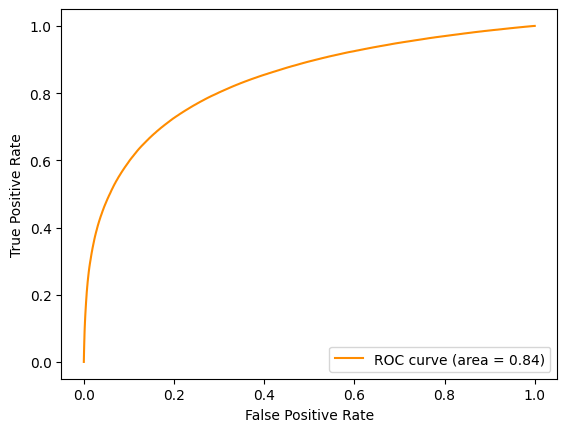

In [17]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [24]:
# Part b)
# Importing metrics
from sklearn.metrics import (roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score)

def compute_metrics(model, var_list, threshold=0.5):
    X_train = Train_Sample[var_list]
    X_test = Test_Sample[var_list]

    model.fit(X_train, y_Train)

    # Get scores
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_Test)
    else:
        scores = model.preddict_proba(X_Test)[:, 1]

    # ROC & AUC
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)

    # Scores into binary predictions
    y_pred = (scores > threshold).astype(int)

    # Metrics
    precision = precision_score(y_Test, y_pred)
    recall = recall_score(y_Test, y_pred)
    f1 = f1_score(y_Test, y_pred)
    accuracy = accuracy_score(y_Test, y_pred)

    # Retrieving values
    return {"AUC": roc_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Accuracy": accuracy,
        "FPR_curve": fpr,
        "TPR_curve": tpr,
        "scores": scores}

# Running with our besst model
gb = HistGradientBoostingClassifier()
results = compute_metrics(gb, combined_vars)

# Extracting scores
scores = results["scores"]
scores_sig = scores[y_Test == 1]
scores_bkg = scores[y_Test == 0]

# Scenarios from last lab
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)]

# Building table
# Empty list to store results
table = []

# Loop over scenarios
for Ns, Nb in scenarios:
    # Computing significance
    sigma = max_significance(scores_sig, scores_bkg, Ns, Nb)

    # Building a row for table
    row = [Ns, Nb,
        results["AUC"],
        results["Precision"],
        results["Recall"],
        results["F1"],
        results["Accuracy"],
        sigma]
    # Add row to table
    table.append(row)

# Displaying the table to label each column
headers = ["N_S", "N_B", "AUC", "Precision", "Recall", "F1", "Accuracy", "Max Significance"]

# Converts list into clean table
# tablefmt="grid" makes it look nicer
print(tabulate.tabulate(table, headers=headers, tablefmt="grid"))

+-------+--------+----------+-------------+----------+----------+------------+--------------------+
|   N_S |    N_B |      AUC |   Precision |   Recall |       F1 |   Accuracy |   Max Significance |
+=======+========+==========+=============+==========+==========+============+====================+
|    10 |    100 | 0.876002 |    0.878906 | 0.639917 | 0.740609 |   0.794597 |            1.82338 |
+-------+--------+----------+-------------+----------+----------+------------+--------------------+
|   100 |   1000 | 0.876002 |    0.878906 | 0.639917 | 0.740609 |   0.794597 |            5.76604 |
+-------+--------+----------+-------------+----------+----------+------------+--------------------+
|  1000 |  10000 | 0.876002 |    0.878906 | 0.639917 | 0.740609 |   0.794597 |           18.2338  |
+-------+--------+----------+-------------+----------+----------+------------+--------------------+
| 10000 | 100000 | 0.876002 |    0.878906 | 0.639917 | 0.740609 |   0.794597 |           57.6604  |
